[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/neuromatch/climate-course-content/blob/main/tutorials/W1D3_RemoteSensing/student/W1D3_Tutorial6.ipynb)   <a href="https://kaggle.com/kernels/welcome?src=https://raw.githubusercontent.com/neuromatch/climate-course-content/main/tutorials/W1D3_RemoteSensing/student/W1D3_Tutorial6.ipynb" target="_blank"><img alt="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"/></a>

# More Xarray: Large Scale Climate Variability - ENSO

This tutorial is adapted from the excellent materials of the [Climate Match Academy: Tutorial 6: Large Scale Climate Variability - ENSO](https://comptools.climatematch.io/tutorials/W1D3_RemoteSensing/student/W1D3_Tutorial6.html) that provides a comprehensive introduction to computational tools in climate science. 

## Tutorial Objectives

In this tutorial, we will use the El Niño-Southern Oscillation (ENSO) to investigate correlations between precipitation anomalies and ENSO. ENSO is recognized as one of the most influential large-scale climate variabilities that impact weather and climate patterns.

By the end of this tutorial, you will:

- Enhance your comprehension of the concept of ENSO and the three distinct phases associated with it.
- Utilize satellite-derived sea surface temperature (SST) data to compute an index for monitoring ENSO.

### Technical skills

- Use Xarray to read and process climate data files
- Use groupby and rolling to investigate and visualize temporal and spatial patterns including 
    - climatologies
    - anomalies
- Plot xarray data on maps and format the output
- Calculate rolling averages 

## Setup

In [1]:
# imports
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import os
import pooch
import tempfile


## Section 1: El Niño-Southern Oscillation (ENSO)


As you learned in Day 1 and 2, one of the most significant large-scale climate variabilities is El Niño-Southern Oscillation (ENSO). ENSO can change the global atmospheric circulation, which in turn, influences temperature and precipitation across the globe.

Despite being a single climate phenomenon, ENSO exhibits three distinct phases:

- El Niño: A warming of the ocean surface, or above-average sea surface temperatures, in the central and eastern tropical Pacific Ocean.
- La Niña: A cooling of the ocean surface, or below-average sea surface temperatures, in the central and eastern tropical Pacific Ocean.
- Neutral: Neither El Niño or La Niña. Often tropical Pacific SSTs are generally close to average. 

In Day 2, you practiced utilizing a variety of Xarray tools to examine variations in sea surface temperature (SST) during El Niño and La Niña events by calculating the [Oceanic Niño Index (ONI)](https://climatedataguide.ucar.edu/climate-data/nino-sst-indices-nino-12-3-34-4-oni-and-tni) from reanalysis data over the time period 2000-2014.

In contrast to previous days, in this tutorial, you will use satellite-based SST data to monitor ENSO over a longer time period starting in 1981.

### Section 1.1: Calculate SST Anomaly

[Optimum Interpolation Sea Surface Temperature (OISST)](https://www.ncei.noaa.gov/products/optimum-interpolation-sst) is a long-term Climate Data Record that incorporates observations from different platforms (satellites, ships, buoys, and Argo floats) into a regular global grid. OISST data is originally produced at daily and 1/4° spatial resolution. To avoid the large amount of data processing of daily data, we use the monthly aggregated OISST SST data provided by [NOAA Physical Systems Laboratory](https://psl.noaa.gov/). 

In [16]:
# download the monthly sea surface temperature data from NOAA Physical System
# Laboratory. The data is processed using the OISST SST Climate Data Records
# from the NOAA CDR program.
# the data downloading may take 2-3 minutes to complete.
# filename=sst.mon.mean.nc
url_sst = "https://osf.io/6pgc2/download/sst.mon.mean.nc"

fname = pooch.retrieve(url_sst ,
                       known_hash=None
                      )
print(fname)


# we divide the data into small chunks to allow for easier memory manangement. this is all done automatically, no need for you to do anything
ds = xr.open_dataset(fname,
                     chunks={"time": 25, "latitude": 200, "longitude": 200},
)
ds

/Users/oliviajose/Library/Caches/pooch/97ba9b9b80506aceff2df92f32e66a12-sst.mon.mean.nc


<xarray.Dataset> Size: 2GB
Dimensions:  (time: 499, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1981-09-01 1981-10-01 ... 2023-03-01
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    sst      (time, lat, lon) float32 2GB dask.array<chunksize=(25, 720, 1440), meta=np.ndarray>
Attributes:
    Conventions:    CF-1.5
    title:          NOAA/NCEI 1/4 Degree Daily Optimum Interpolation Sea Surf...
    institution:    NOAA/National Centers for Environmental Information
    source:         NOAA/NCEI https://www.ncei.noaa.gov/data/sea-surface-temp...
    References:     https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2....
    dataset_title:  NOAA Daily Optimum Interpolation Sea Surface Temperature
    version:        Version 2.1
    comment:        Reynolds, et al.(2007) Daily High-Resolution-Blended Anal...

The monthly OISST data is available starting from September of 1981. We will use the Niño 3.4 (5N-5S, 170W-120W) region to monitor the ENSO as identified in the map below provided by the NOAA Climate portal.

![Location of four different nino regions ](https://www.climate.gov/sites/default/files/Fig3_ENSOindices_SST_large.png)

Credit: [NOAA](https://www.climate.gov/sites/default/files/Fig3_ENSOindices_SST_large.png)

The data is only available in full years starting 1982, so we will use 1982-2011 as the climatology period.

In [17]:
# get 30-year climatology from 1982-2011
sst_30yr = ds.sst.sel(time=slice("1982-01-01", "2011-12-01"))

# calculate monthly climatology
sst_clim = sst_30yr.groupby("time.month").mean()
sst_clim

<xarray.DataArray 'sst' (month: 12, lat: 720, lon: 1440)> Size: 50MB
dask.array<stack, shape=(12, 720, 1440), dtype=float32, chunksize=(1, 720, 1440), chunktype=numpy.ndarray>
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Attributes:
    long_name:      Monthly Mean of Sea Surface Temperature
    units:          degC
    valid_range:    [-3. 45.]
    precision:      2.0
    dataset:        NOAA High-resolution Blended Analysis
    var_desc:       Sea Surface Temperature
    level_desc:     Surface
    statistic:      Monthly Mean
    parent_stat:    Individual Observations
    actual_range:   [-1.8  32.14]
    standard_name:  sea_surface_temperature

In [18]:
# calculate monthly anomaly
sst_anom = ds.sst.groupby("time.month") - sst_clim
sst_anom

<xarray.DataArray 'sst' (time: 499, lat: 720, lon: 1440)> Size: 2GB
dask.array<sub, shape=(499, 720, 1440), dtype=float32, chunksize=(1, 720, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 4kB 1981-09-01 1981-10-01 ... 2023-03-01
    month    (time) int64 4kB 9 10 11 12 1 2 3 4 5 6 ... 6 7 8 9 10 11 12 1 2 3
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Attributes:
    long_name:      Monthly Mean of Sea Surface Temperature
    units:          degC
    valid_range:    [-3. 45.]
    precision:      2.0
    dataset:        NOAA High-resolution Blended Analysis
    var_desc:       Sea Surface Temperature
    level_desc:     Surface
    statistic:      Monthly Mean
    parent_stat:    Individual Observations
    actual_range:   [-1.8  32.14]
    standard_name:  sea_surface_temperature

Now, we can take a look at the SST anomaly of a given month. We use January of 1998 to show the specific change of SST during that time period.

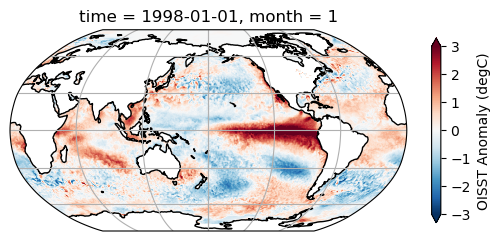

In [19]:
sst = sst_anom.sel(time="1998-01-01")

# initiate plot
fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.Robinson(central_longitude=180)},
    #figsize=(9, 6)
)

# focus on the ocean with the central_longitude=180
ax.coastlines()
ax.gridlines()
sst.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    vmin=-3,
    vmax=3,
    cmap="RdBu_r",    
    cbar_kwargs=dict(shrink=0.5, label="OISST Anomaly (degC)"),
)

This is a good time to look at the code that controls the plot of sst (`sst.plot()`). There are several arguments including `vmin`, `vmax`, and `cmap`. Think about what each of these options does. 
`cmap` stands for colormap. All available colormaps are can be found in the [matplotlib colormap reference page](https://matplotlib.org/stable/gallery/color/colormap_reference.html).

### Section 1.2: Monitoring ENSO with Oceanic Niño Index

The [Oceanic Niño Index (ONI)](https://climatedataguide.ucar.edu/climate-data/nino-sst-indices-nino-12-3-34-4-oni-and-tni) is a common index used to monitor ENSO. It is calculated using the Niño 3.4 region (5N-5S, 170W-120W) and by applying a 3-month rolling mean to the mean SST anomalies in that region.

You may have noticed that the `lon` for the SST data from [NOAA Physical Systems Laboratory](https://psl.noaa.gov/) is organized between 0°–360°E. We find that the region to subset with our dataset is (-5° to 5°, 190 to 240°).

In [20]:
# extract SST data from the Nino 3.4 region
sst_nino34 = sst_anom.sel(lat=slice(-5, 5), lon=slice(190, 240))
sst_nino34

<xarray.DataArray 'sst' (time: 499, lat: 40, lon: 200)> Size: 16MB
dask.array<getitem, shape=(499, 40, 200), dtype=float32, chunksize=(1, 40, 200), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 4kB 1981-09-01 1981-10-01 ... 2023-03-01
    month    (time) int64 4kB 9 10 11 12 1 2 3 4 5 6 ... 6 7 8 9 10 11 12 1 2 3
  * lat      (lat) float32 160B -4.875 -4.625 -4.375 ... 4.375 4.625 4.875
  * lon      (lon) float32 800B 190.1 190.4 190.6 190.9 ... 239.4 239.6 239.9
Attributes:
    long_name:      Monthly Mean of Sea Surface Temperature
    units:          degC
    valid_range:    [-3. 45.]
    precision:      2.0
    dataset:        NOAA High-resolution Blended Analysis
    var_desc:       Sea Surface Temperature
    level_desc:     Surface
    statistic:      Monthly Mean
    parent_stat:    Individual Observations
    actual_range:   [-1.8  32.14]
    standard_name:  sea_surface_temperature

In [23]:
# calculate the mean values for the Nino 3.4 region
nino34 = sst_nino34.mean(dim=["lat", "lon"])

You might have realized the block-like visualizations and tables that appeared once you called a dataset like `sst_nino34` or `sst_anom`. They refer to some advanced built-in data structuring called [***Dask array***]() that is used to handle large datasets in `xarray` via [parallelization](https://docs.xarray.dev/en/stable/user-guide/dask.html#parallel-computing-with-dask). We do not cover this topic here, however, took advantage of its capabilities before to fasten our computations. Be aware that you might have to dive deeper into this optimization procedures the larger your project data sets are going to be. The following cell is a work-around to improve the following time series calculations. It saves our `sst` anomaly time series to a file and opens it again. You do not have to understand why this is necessary but feel free to explore [this resource on optimization](https://docs.xarray.dev/en/stable/user-guide/dask.html#optimization-tips) if you became curious.

In [24]:
nino34

<xarray.DataArray 'sst' (time: 499)> Size: 2kB
dask.array<mean_agg-aggregate, shape=(499,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 4kB 1981-09-01 1981-10-01 ... 2023-03-01
    month    (time) int64 4kB 9 10 11 12 1 2 3 4 5 6 ... 6 7 8 9 10 11 12 1 2 3
Attributes:
    long_name:      Monthly Mean of Sea Surface Temperature
    units:          degC
    valid_range:    [-3. 45.]
    precision:      2.0
    dataset:        NOAA High-resolution Blended Analysis
    var_desc:       Sea Surface Temperature
    level_desc:     Surface
    statistic:      Monthly Mean
    parent_stat:    Individual Observations
    actual_range:   [-1.8  32.14]
    standard_name:  sea_surface_temperature

In [ ]:
# plot time series for Nino 3.4 mean anomaly
fig, ax = plt.subplots()
nino34.plot(ax=ax)
# aesthetics
ax.set_xlabel("Time (months)")
ax.set_ylabel("Nino3.4 Anomaly (degC)")
ax.axhline(y=0, color="k", linestyle="dashed")

The ONI is defined as the 3-month rolling mean of the monthly regional average of the SST anomaly for the Nino 3.4 region. We can use `.rolling()` to calculate the ONI value for each month from the OISST monthly anomaly.

In [ ]:
# calculate 3-month rolling mean of Nino 3.4 anomaly for the ONI
oni = nino34.rolling(time=3, center=True).mean()

# generate time series plot
fig, ax = plt.subplots()
nino34.plot(label="Nino 3.4", ax=ax)
oni.plot(color="k", label="ONI", ax=ax)
# aesthetics
ax.set_xlabel("Time (months)")
ax.set_ylabel("Anomaly (degC)")
ax.axhline(y=0, color="k", linestyle="dashed")
ax.legend()

The different phases of ENSO are nominally defined based on a threshold of $\pm$ 0.5 with the ONI index. 

- [El Niño](https://glossary.ametsoc.org/wiki/El_niño) [ONI values higher than 0.5]: surface waters in the east-central tropical Pacific are at least 0.5 degrees Celsius *warmer than normal*.
- [La Niña](https://glossary.ametsoc.org/wiki/La_niña) [ONI values lower than -0.5]: surface waters in the west tropical Pacific are at least 0.5 degrees Celsius *cooler than normal*.

The neutral phase is when ONI values are in between these two thresholds. Let's create the ONI plot that is used by NOAA and other organizations to monitor ENSO phases.

In [ ]:
# set up the plot size
fig, ax = plt.subplots()

# create the filled area when ONI values are above 0.5 for El Nino
ax.fill_between(
    oni.time.data,
    oni.where(oni >= 0.5).data,
    0.5,
    color="red",
    alpha=0.9,
)

# create the filled area when ONI values are below -0.5 for La Nina
ax.fill_between(
    oni.time.data,
    oni.where(oni <= -0.5).data,
    -0.5,
    color="blue",
    alpha=0.9,
)

# create the time series of ONI
oni.plot(color="black", ax=ax)

# add the threshold lines on the plot
ax.axhline(0, color="black", lw=0.5)
ax.axhline(0.5, color="red", linewidth=0.5, linestyle="dotted")
ax.axhline(-0.5, color="blue", linewidth=0.5, linestyle="dotted")
# aesthetics
ax.set_title("Oceanic Niño Index")
ax.set_xlabel('Time (months)')
ax.set_ylabel('ONI')

From the plot, we can see the historical ENSO phases swing from El Niño to La Niña events. The major ENSO events like 1997-1998 show up very clearly on the ONI plot. 

We will use the ONI data to perform analysis to understand the impact of ENSO on precipitation. So you can export the ONI time series into a netCDF file for future use via [`.to_netcdf()`](https://docs.xarray.dev/en/latest/generated/xarray.Dataset.to_netcdf.html). For our purposes, we will download a dataset that has been previously saved in the next tutorial. If you wanted to save the data when working on your own computer, this is the code you could use.

In [ ]:
oni.to_netcdf('../Data/t6_oceanic-nino-index.nc')

#### Coding Exercises 1.2

As we learned here, ENSO is monitored using the anomaly of SST data for a specific region (e.g., Nino 3.4). We also learned previously that the reference periods used to calculate climatolgies are updated regularly to reflect the most up to date 'normal'.

1. Compare the ONI time series calculated using two different climatology reference periods (1982-2011 v.s. 1991-2020). 

NameError: name 'oni' is not defined

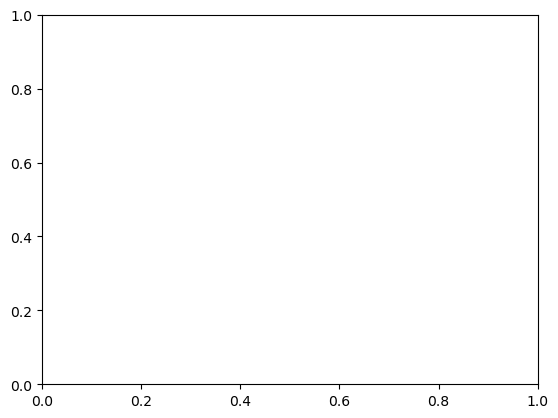

In [30]:
# select data from 1991-2020.
sst_30yr_later = ds.sst.sel(time=slice("1991-01-01", "2020-12-01"))

# calculate climatology
sst_clim_later = sst_30yr_later.groupby("time.month").mean()

# calculate anomaly
sst_anom_later = ds.sst.groupby("time.month") - sst_clim_later

# calculate mean over Nino 3.4 region
nino34_later = sst_anom_later.sel(lat=slice(-5, 5), lon=slice(190, 240)).mean(
    dim=["lat", "lon"])
# nino34_later.mean(dim=["lat", "lon"])

# compute 3 month rolling mean
oni_later = nino34_later.rolling(time=3, center=True).mean()

# compare the two ONI time series and visualize the difference as a time series plot
fig, ax = plt.subplots()
# ONI (1982-2011)
_ = oni.plot(color="k", label="ONI (1982-2011)", ax=ax)
# ONI (1991-2020)
_ = oni.plot(color="k", label="ONI (1991-2020)", ax=ax)

# aesthetics
ax.set_xlabel('Time (months)')
ax.set_ylabel("Anomaly (degC)")
ax.axhline(y=0, color="k", linestyle="dashed")
ax.legend()

[*Click for solution*](https://github.com/neuromatch/climate-course-content/tree/main/tutorials/W1D3_RemoteSensing/solutions/W1D3_Tutorial6_Solution_3efa1010.py)

*Example output:*

<img alt='Solution hint' align='left' width=775.0 height=575.0 src=https://raw.githubusercontent.com/neuromatch/climate-course-content/main/tutorials/W1D3_RemoteSensing/static/W1D3_Tutorial6_Solution_3efa1010_2.png>



#### Questions 1.2: Climate Connection

1. What is the main difference you note about this plot?
2. What does this tell you about the climatology calculated from 1982-2011 versus 1991-2020?
3. Why is it important to use appropriate climatologies when finding anomalies?

[*Click for solution*](https://github.com/neuromatch/climate-course-content/tree/main/tutorials/W1D3_RemoteSensing/solutions/W1D3_Tutorial6_Solution_52e2ab81.py)



## Summary

In this tutorial, you revisted the foundational principles of ENSO and explored how satellite data can be employed to track this phenomenon. 
- As one of the most potent climate influences on Earth, ENSO has the capacity to alter global atmospheric circulation with impacts around the world.
- You observed the three phases of ENSO by utilizing SST data gathered from satellites and calculating the Oceanic Niño Index.

In the forthcoming tutorial, we will utilize the ONI, calculated in this session, to evaluate the influence of ENSO on precipitation in select regions. 


## Resources

Data from this tutorial can be accessed [here](https://www.ncei.noaa.gov/products/optimum-interpolation-sst).